# Три модели: Vanilla mPPCA vs MS-mPPCA (Normal) vs MS-mPPCA + Student-t VaR

MS-Normal показал breach rate ≈2.2% при целевом 1% — гауссовы хвосты не догоняют экстремальные потери.

**Подход (per-α откалиброванный ν)**: параметры рассеяния $(μ_k, W_k, σ²_k)$ берутся из MS-Normal без изменений;
квантиль $\Phi^{-1}(\alpha)$ заменяется на $t_{\nu_\alpha}^{-1}(\alpha)$.
Значение $\nu_\alpha$ калибруется отдельно для каждого $\alpha$ методом бисекции:
найти $\nu$ такое, что частота нарушений EW-портфеля совпадает с $\alpha$.
Переобучение не требуется — используется кешированный артефакт MS-Normal.

> Вариант с обучаемым $\nu$ (Student-t EM) отклонён: `normalize_window` стандартизирует каждое окно,
> удаляя межоконную дисперсию, и EM обоснованно оценивает $\nu \to \infty$.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import t as scipy_t

from src.data.loader import download
from src.data.preprocessing import get_returns_array
from src.models.rolling import load as load_vanilla, load_ms, fit_rolling_ms, save_ms
from src.models.var import (
    compute_var_multi_level,
    compute_var_multi_level_fixed_nu,
    calibrate_nu_per_alpha,
)
from src.backtesting.portfolios import generate_diversified, generate_non_diversified
from src.backtesting.backtest import aggregate_results, breach_series

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})
sns.set_palette('tab10')

VANILLA_ARTIFACT = '../data/basic-pipeline/rolling_fit.npz'
MS_NORMAL_DIR    = '../data/ms-mppca'
MS_NORMAL_ART    = f'{MS_NORMAL_DIR}/rolling_fit_ms.npz'

WINDOW = 350
ALPHAS = [0.05, 0.01]
N_PORT = 200

import os
os.makedirs(MS_NORMAL_DIR, exist_ok=True)

## 1. Загрузка данных и артефактов

In [2]:
prices = download(cache=True)
returns, dates, tickers = get_returns_array(prices)
T, D = returns.shape

vanilla = load_vanilla(VANILLA_ARTIFACT)
T_out = vanilla.means_hist.shape[0]
K     = vanilla.means_hist.shape[1]
q     = vanilla.W_hist.shape[3]
D_art = vanilla.means_hist.shape[2]
assert D == D_art, f'D mismatch: {D} vs {D_art} — delete artifacts and refit'

oos_dates = dates[WINDOW : WINDOW + T_out]
oos_ret   = returns[WINDOW : WINDOW + T_out]
eq_w      = np.ones(D) / D

print(f'Assets D={D}, latent q={q}, regimes K={K}')
print(f'OOS windows: {T_out}  ({oos_dates[0].date()} -> {oos_dates[-1].date()})')

Loading cached data from /Users/ivan/Projects/mipt/ms-mppca-coupling-diploma/notebooks/../data/sp500_adj_close.csv
Assets D=79, latent q=3, regimes K=2
OOS windows: 4681  (2006-05-25 -> 2024-12-30)


In [3]:
# MS-mPPCA Normal
if os.path.exists(MS_NORMAL_ART):
    print(f'Loading MS-Normal from {MS_NORMAL_ART}')
    ms_norm = load_ms(MS_NORMAL_ART)
else:
    print('Fitting MS-mPPCA (Normal)...')
    ms_norm = fit_rolling_ms(
        returns, window=WINDOW, step=1, n_components=q, n_clusters=K,
        n_iter_init=2000, n_iter_ms_init=200, n_iter_ms=100,
        tol_ms=1e-3, sticky_diag=2.0, hmm_eps=0.05,
        emission='normal', random_state=42,
    )
    save_ms(ms_norm, MS_NORMAL_ART)
    print(f'Saved to {MS_NORMAL_ART}')

print(f'MS-Normal A diag (mean): {ms_norm.A_hist[:, range(K), range(K)].mean(axis=0).round(3)}')

Loading MS-Normal from ../data/ms-mppca/rolling_fit_ms.npz
MS-Normal A diag (mean): [0.799 0.619]


In [4]:
# Per-alpha ν calibration via EW portfolio breach rate bisection
print("Calibrating per-alpha ν (bisection on EW portfolio breach rate)...")
nu_dict = calibrate_nu_per_alpha(ms_norm, oos_ret, ALPHAS)

# Quantile comparison: Normal vs calibrated t for each alpha
from scipy.stats import norm as scipy_norm
print()
for alpha in ALPHAS:
    nu = nu_dict[alpha]
    z_n = scipy_norm.ppf(alpha)
    z_t = scipy_t.ppf(alpha, df=nu)
    print(f'  α={alpha:.0%}: Normal z={z_n:.4f}, t_ν (ν={nu:.1f}) z={z_t:.4f}  '
          f'(ratio={z_t/z_n:.3f})')

Calibrating per-alpha ν (bisection on EW portfolio breach rate)...
  calibrated ν  α=5% → ν=14.45
  calibrated ν  α=1% → ν=6.71

  α=5%: Normal z=-1.6449, t_ν (ν=14.4) z=-1.7575  (ratio=1.068)
  α=1%: Normal z=-2.3263, t_ν (ν=6.7) z=-3.0342  (ratio=1.304)


## 2. Сравнение log-likelihood

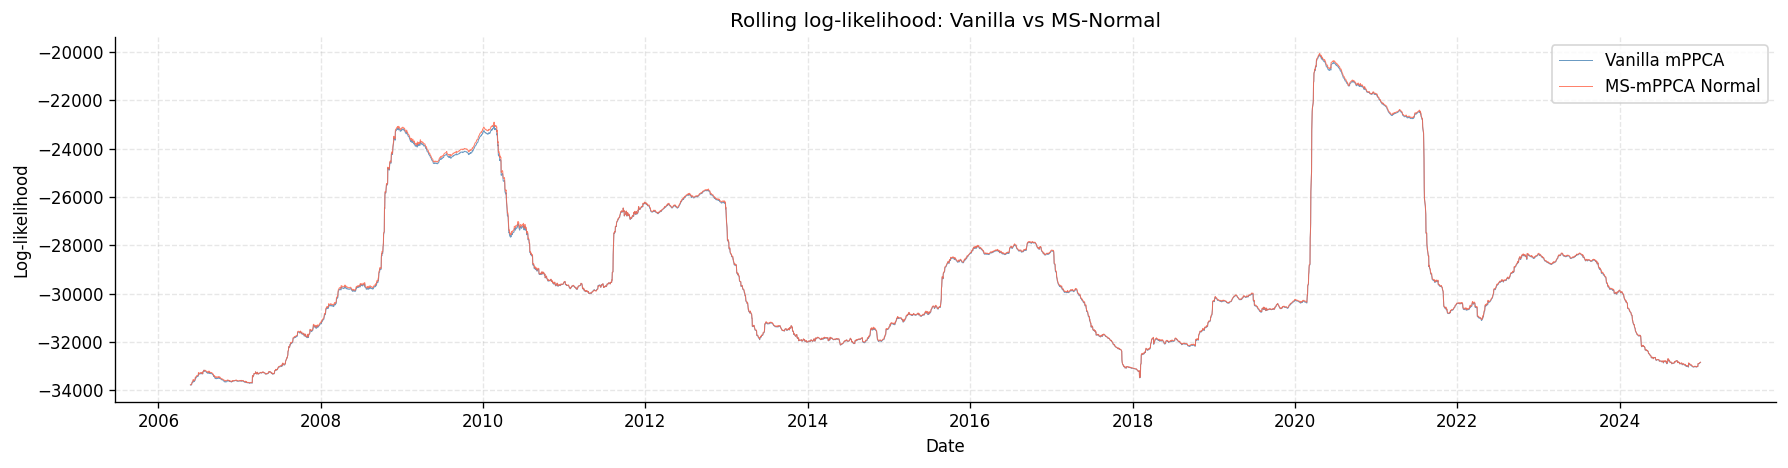

MS-Normal vs Vanilla: mean gain 30.91, wins 99.1% of windows
Note: fixed-ν t-VaR reuses the MS-Normal artifact — LLH is identical to MS-Normal.


In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(oos_dates, vanilla.llh_hist, lw=0.6, color='steelblue', alpha=0.8, label='Vanilla mPPCA')
ax.plot(oos_dates, ms_norm.llh_hist, lw=0.6, color='tomato',    alpha=0.8, label='MS-mPPCA Normal')
ax.set_title('Rolling log-likelihood: Vanilla vs MS-Normal')
ax.set_xlabel('Date')
ax.set_ylabel('Log-likelihood')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig(f'{MS_NORMAL_DIR}/fig_llh_2way.png', bbox_inches='tight')
plt.show()

diff = ms_norm.llh_hist - vanilla.llh_hist
print(f'MS-Normal vs Vanilla: mean gain {diff.mean():.2f}, wins {(diff>0).mean()*100:.1f}% of windows')
print('Note: fixed-ν t-VaR reuses the MS-Normal artifact — LLH is identical to MS-Normal.')

## 3. Хвосты: Normal vs $t_\nu$

Откалиброванный $t_\nu$ точнее описывает нижний хвост EW-портфеля, чем нормальное распределение.

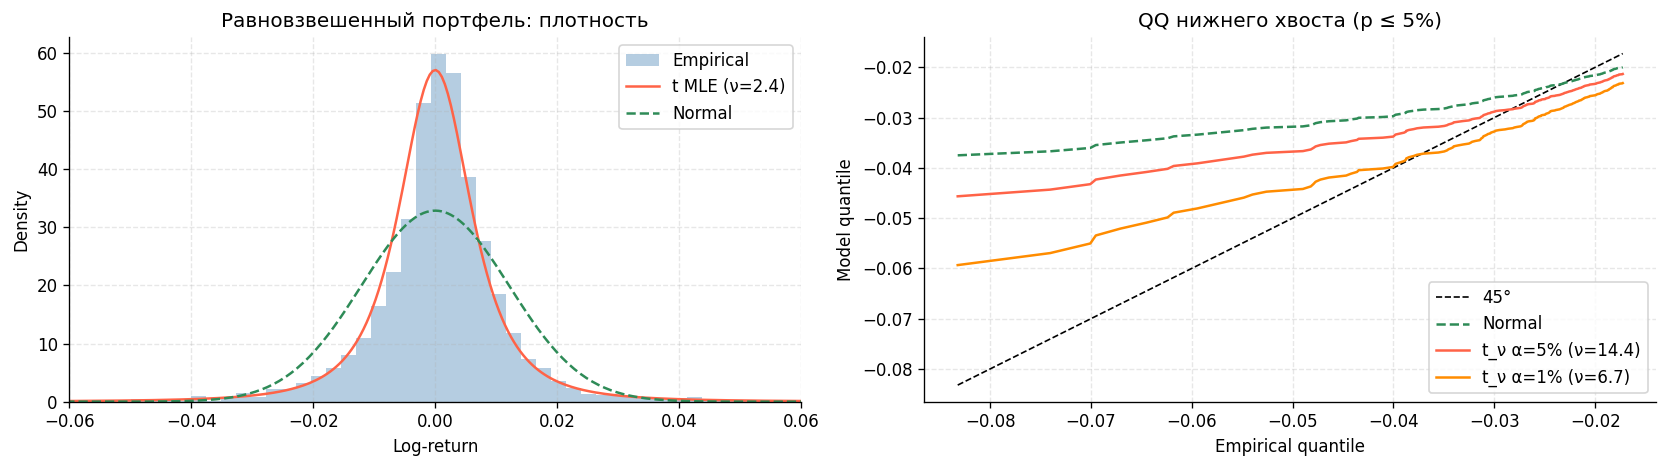

MLE fit: ν=2.41, scale=0.00632
Calibrated per-alpha ν: α=5% → ν=14.45, α=1% → ν=6.71


In [6]:
port_full = returns @ (np.ones(D) / D)

df_fit, loc_fit, scale_fit = scipy_t.fit(port_full, floc=0)
from scipy.stats import norm as scipy_norm

x_grid = np.linspace(port_full.min(), port_full.max(), 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: density (use MLE ν for display only)
axes[0].hist(port_full, bins=100, density=True, alpha=0.4, color='steelblue', label='Empirical')
axes[0].plot(x_grid, scipy_t.pdf(x_grid, df=df_fit, loc=loc_fit, scale=scale_fit),
             color='tomato', lw=1.5, label=f't MLE (ν={df_fit:.1f})')
axes[0].plot(x_grid, scipy_norm.pdf(x_grid, loc=0, scale=port_full.std()),
             color='seagreen', lw=1.5, ls='--', label='Normal')
axes[0].set_xlim(-0.06, 0.06)
axes[0].set_title('Равновзвешенный портфель: плотность')
axes[0].set_xlabel('Log-return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: QQ tail — show per-alpha calibrated ν
p_grid = np.linspace(0.001, 0.05, 200)
emp_q  = np.quantile(port_full, p_grid)
n_q    = scipy_norm.ppf(p_grid, loc=0, scale=port_full.std())
axes[1].plot(emp_q, emp_q, 'k--', lw=1, label='45°')
axes[1].plot(emp_q, n_q,   color='seagreen', lw=1.5, ls='--', label='Normal')
colors = ['tomato', 'darkorange']
for (alpha, nu), color in zip(nu_dict.items(), colors):
    t_q = scipy_t.ppf(p_grid, df=nu, loc=0, scale=port_full.std())
    axes[1].plot(emp_q, t_q, color=color, lw=1.5, label=f't_ν α={alpha:.0%} (ν={nu:.1f})')
axes[1].set_title('QQ нижнего хвоста (p ≤ 5%)')
axes[1].set_xlabel('Empirical quantile')
axes[1].set_ylabel('Model quantile')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{MS_NORMAL_DIR}/fig_tail_fit.png', bbox_inches='tight')
plt.show()

print(f'MLE fit: ν={df_fit:.2f}, scale={scale_fit:.5f}')
print(f'Calibrated per-alpha ν: ' + ', '.join(f'α={a:.0%} → ν={v:.2f}' for a, v in nu_dict.items()))

## 4. VaR: сравнение нарушений для равновзвешенного портфеля

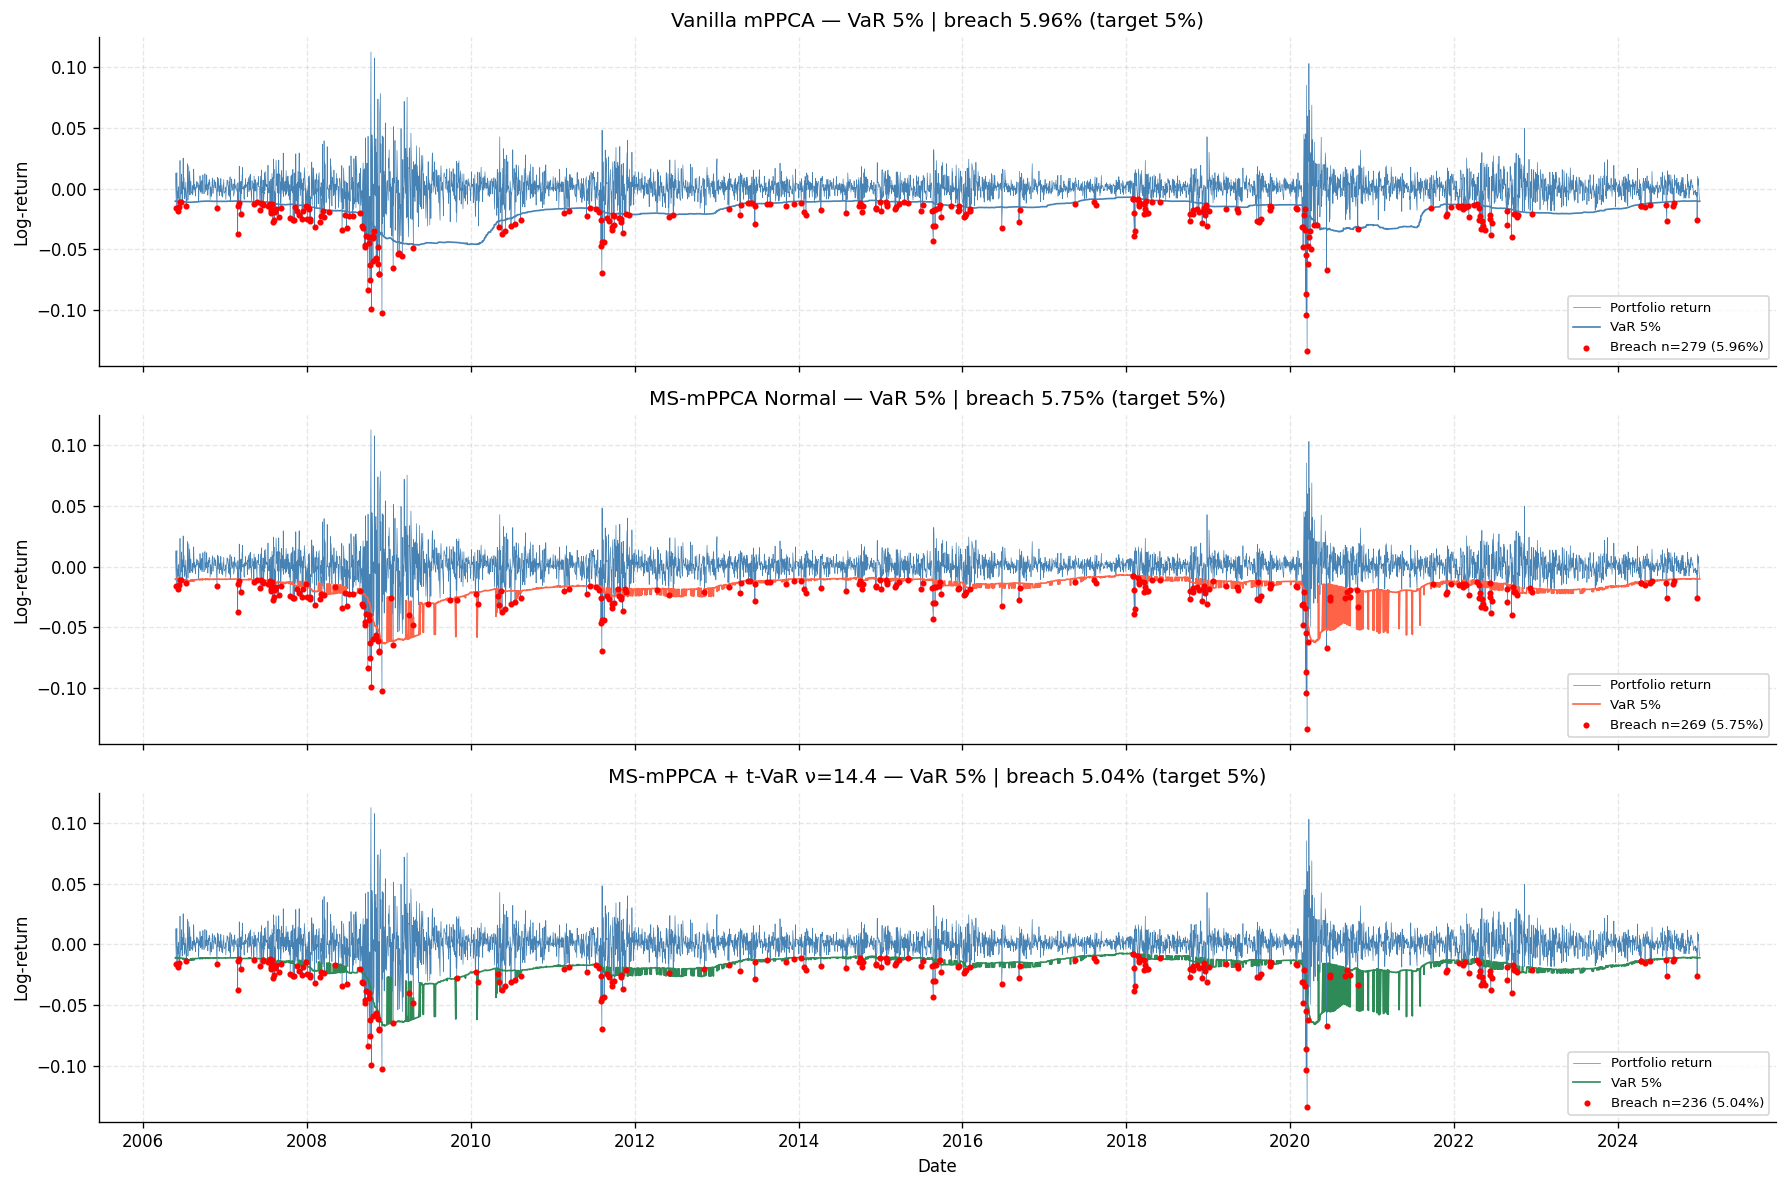

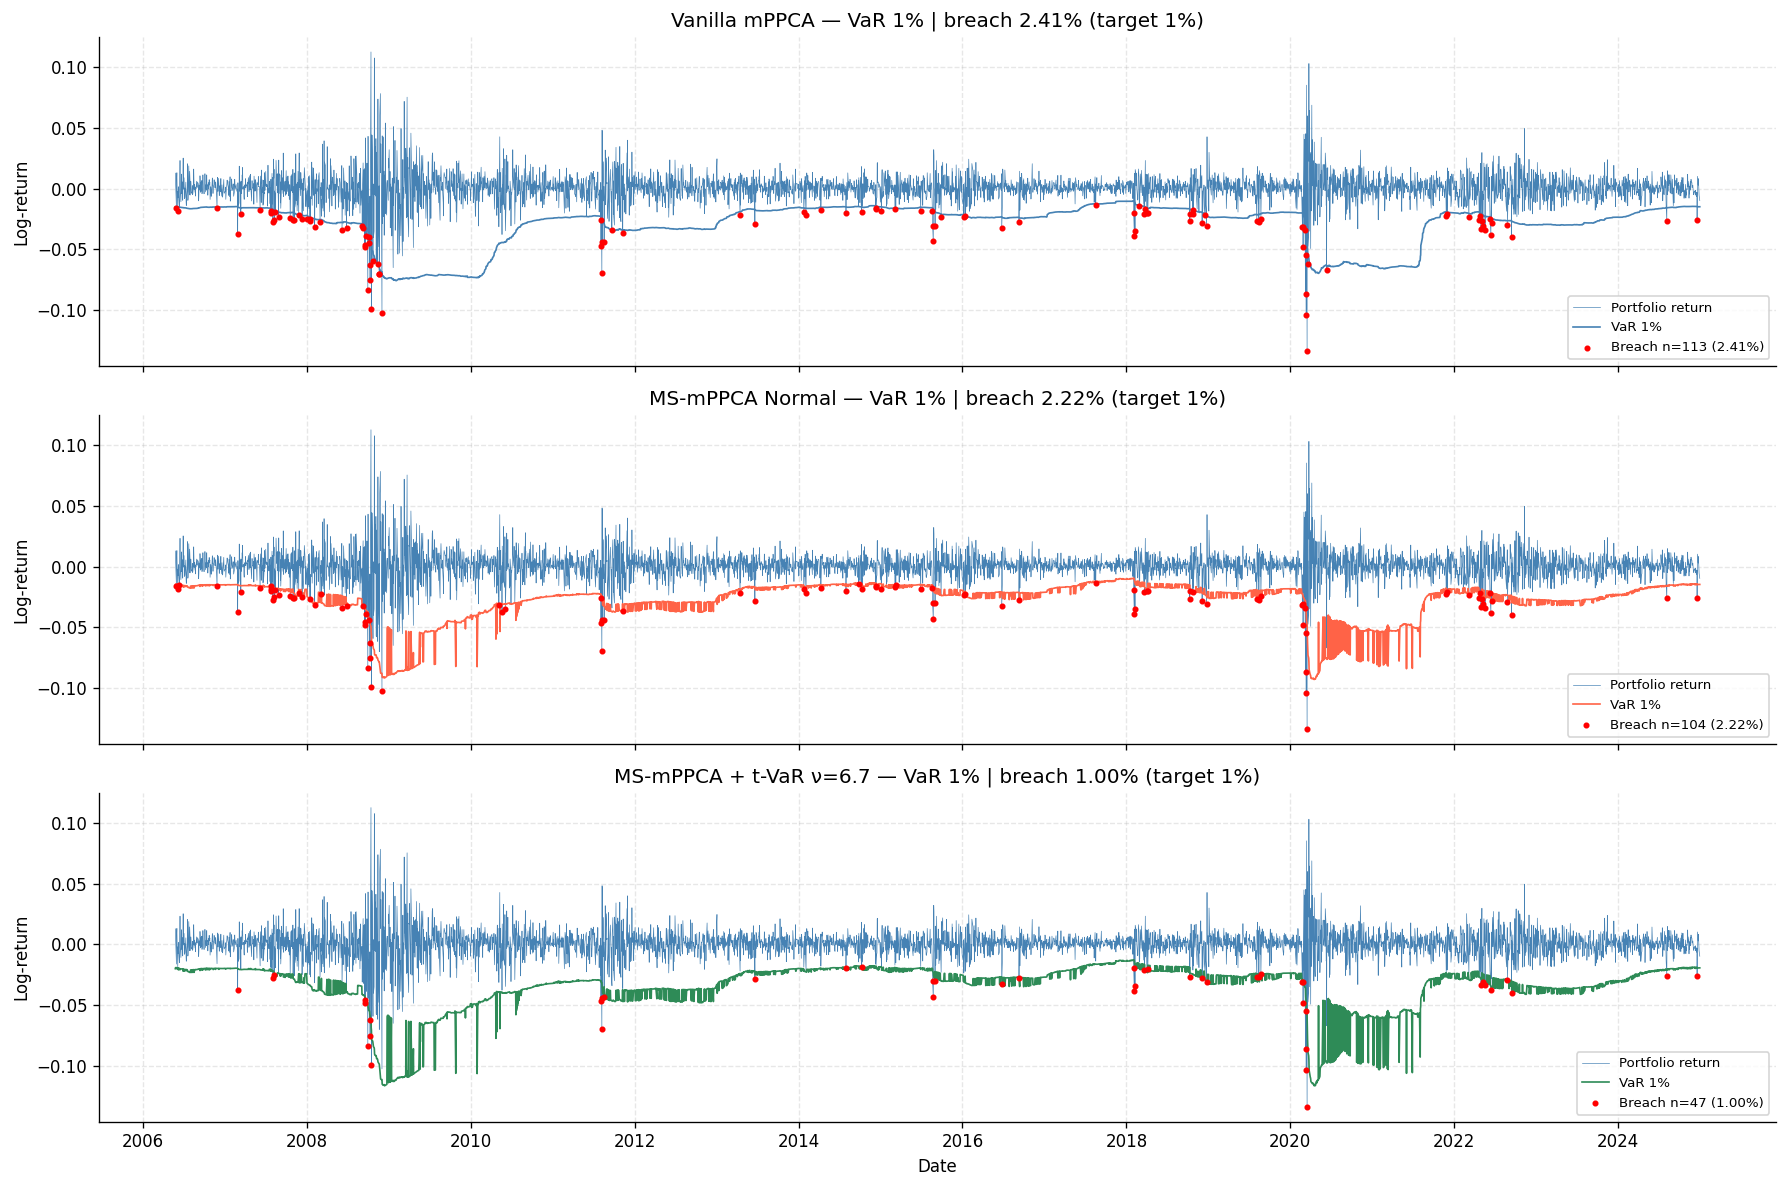

In [7]:
eq_w_2d = eq_w.reshape(1, -1)

vars_v   = compute_var_multi_level(vanilla,  eq_w_2d, ALPHAS)
vars_mn  = compute_var_multi_level(ms_norm,  eq_w_2d, ALPHAS)
vars_mnt = compute_var_multi_level_fixed_nu(ms_norm,  eq_w_2d, ALPHAS, nu_dict)

MODELS_VAR = [
    ('Vanilla mPPCA',       vars_v,   'steelblue'),
    ('MS-mPPCA Normal',     vars_mn,  'tomato'),
    ('MS-mPPCA + t-VaR',    vars_mnt, 'seagreen'),
]

port_oos = oos_ret @ eq_w

for alpha in ALPHAS:
    nu = nu_dict[alpha]
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    for ax, (label, var_dict, color) in zip(axes, MODELS_VAR):
        var_series = var_dict[alpha][0]
        hits = breach_series(port_oos, var_series)
        ax.plot(oos_dates, port_oos, lw=0.4, color='steelblue', label='Portfolio return')
        ax.plot(oos_dates, var_series, lw=1.0, color=color, label=f'VaR {int(alpha*100)}%')
        ax.scatter(oos_dates[hits == 1], port_oos[hits == 1],
                   s=7, color='red', zorder=5,
                   label=f'Breach n={hits.sum()} ({hits.mean()*100:.2f}%)')
        suffix = f' ν={nu:.1f}' if 't-VaR' in label else ''
        ax.set_title(f'{label}{suffix} — VaR {int(alpha*100)}% | breach {hits.mean()*100:.2f}% (target {alpha*100:.0f}%)')
        ax.set_ylabel('Log-return')
        ax.legend(loc='lower right', fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{MS_NORMAL_DIR}/fig_var_3way_{int(alpha*100)}.png', bbox_inches='tight')
    plt.show()

## 5. Бэктест: Купик и Кристофферсен — три модели

In [8]:
portfolios_div    = generate_diversified(N_PORT, D)
portfolios_nondiv = generate_non_diversified(N_PORT, D)

vars_v_div   = compute_var_multi_level(vanilla,  portfolios_div,    ALPHAS)
vars_mn_div  = compute_var_multi_level(ms_norm,  portfolios_div,    ALPHAS)
vars_mnt_div = compute_var_multi_level_fixed_nu(ms_norm, portfolios_div,    ALPHAS, nu_dict)

vars_v_nd    = compute_var_multi_level(vanilla,  portfolios_nondiv, ALPHAS)
vars_mn_nd   = compute_var_multi_level(ms_norm,  portfolios_nondiv, ALPHAS)
vars_mnt_nd  = compute_var_multi_level_fixed_nu(ms_norm, portfolios_nondiv, ALPHAS, nu_dict)

In [9]:
COLS = ['breach_rate', 'pvalue', 'pvalue_pass', 'ci_95_pass', 'ci_99_pass', 'ind_pass']
COL_RENAME = {
    'breach_rate': 'Breach rate',
    'pvalue'     : 'p-value (Kupiec)',
    'pvalue_pass': 'Kupiec passed',
    'ci_95_pass' : 'CI 95% passed',
    'ci_99_pass' : 'CI 99% passed',
    'ind_pass'   : 'Christoffersen passed',
}

for port_label, portfolios, v_vars, mn_vars, mnt_vars in [
    ('Diversified',  portfolios_div,    vars_v_div,  vars_mn_div,  vars_mnt_div),
    ('Concentrated', portfolios_nondiv, vars_v_nd,   vars_mn_nd,   vars_mnt_nd),
]:
    print(f'\n{"="*72}')
    print(f'  {port_label} portfolios')
    print('='*72)
    rows = []
    for alpha in ALPHAS:
        nu = nu_dict[alpha]
        for name, var_dict in [
            ('Vanilla  ',       v_vars),
            ('MS-Normal',       mn_vars),
            (f'MS-t(ν={nu:.1f})', mnt_vars),
        ]:
            df = aggregate_results(portfolios, oos_ret, var_dict[alpha], alpha)
            df.index = [f'{name}  α={alpha}']
            rows.append(df)
    display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))


  Diversified portfolios


,Breach rate,p-value (Kupiec),Kupiec passed,CI 95% passed,CI 99% passed,Christoffersen passed
Vanilla α=0.05,0.0592,0.0050,0.0,0.00,0.045,0.000
MS-Normal α=0.05,0.0570,0.0324,0.1,0.18,1.000,0.000
MS-t(ν=14.4) α=0.05,0.0498,0.9208,1.0,1.00,1.000,0.000
Vanilla α=0.01,0.0240,0.0000,0.0,0.00,0.000,0.000
MS-Normal α=0.01,0.0219,0.0000,0.0,0.00,0.000,0.455
MS-t(ν=6.7) α=0.01,0.0101,0.9044,1.0,1.00,1.000,0.000



  Concentrated portfolios


,Breach rate,p-value (Kupiec),Kupiec passed,CI 95% passed,CI 99% passed,Christoffersen passed
Vanilla α=0.05,0.0548,0.2463,0.635,0.655,0.795,0.050
MS-Normal α=0.05,0.0524,0.3702,0.820,0.830,0.955,0.340
MS-t(ν=14.4) α=0.05,0.0450,0.2484,0.630,0.630,0.785,0.300
Vanilla α=0.01,0.0189,0.0004,0.005,0.005,0.005,0.235
MS-Normal α=0.01,0.0174,0.0027,0.015,0.015,0.030,0.435
MS-t(ν=6.7) α=0.01,0.0076,0.2069,0.630,0.630,0.855,0.725


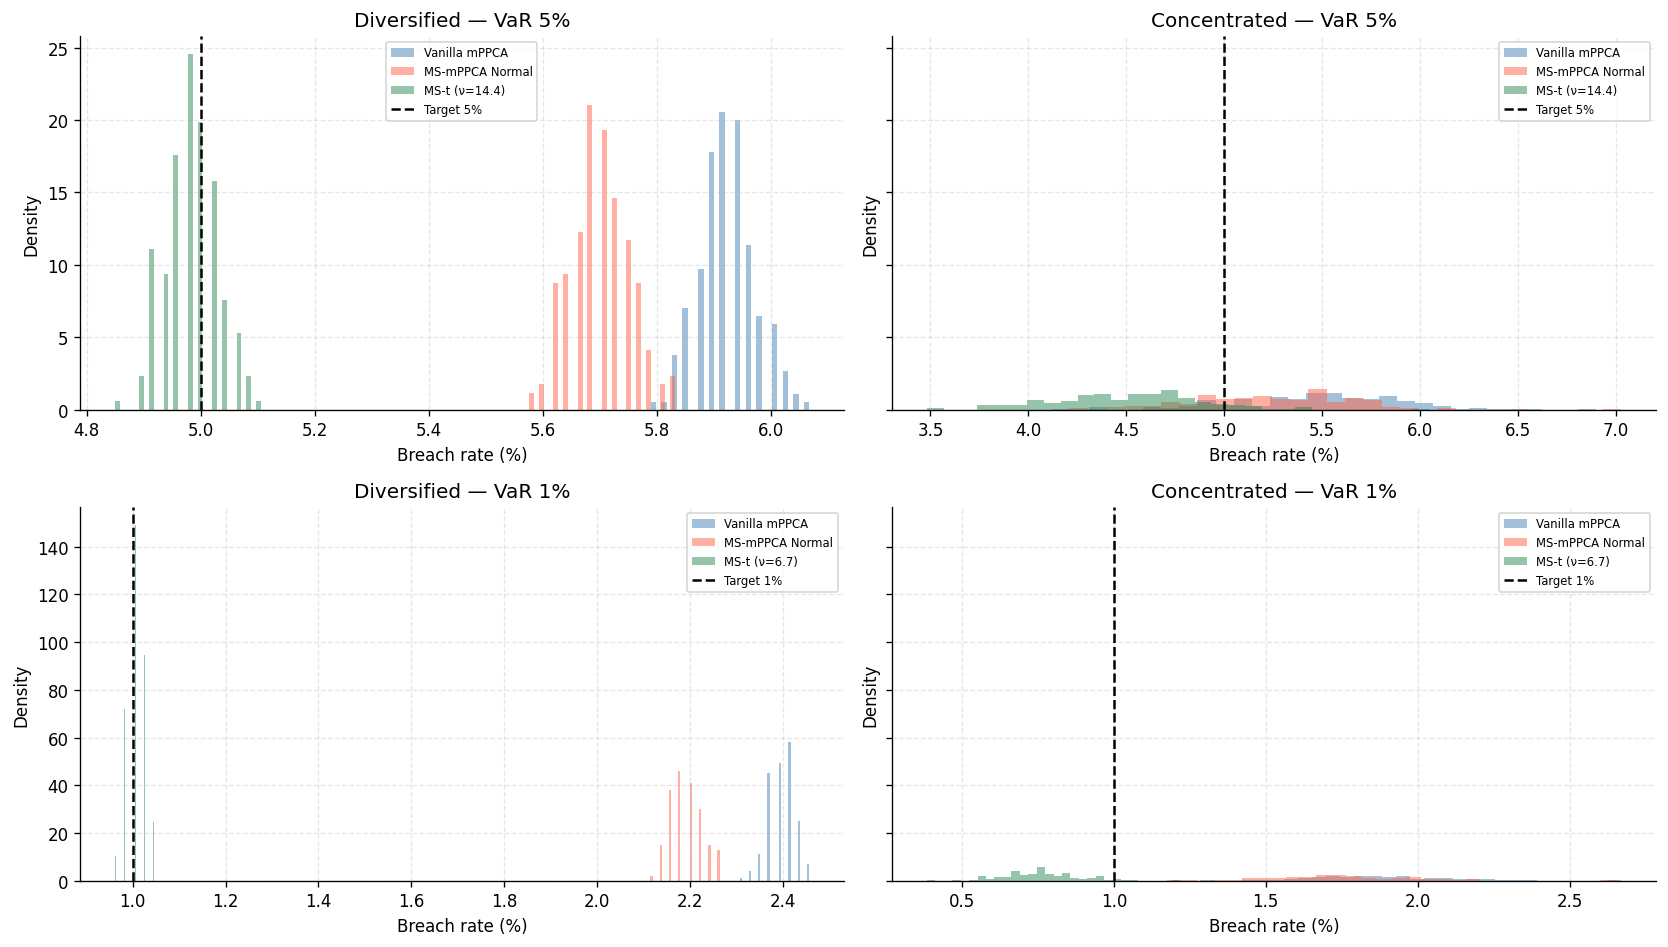

In [10]:
fig, axes = plt.subplots(len(ALPHAS), 2, figsize=(14, 4 * len(ALPHAS)), sharey='row')

for row, alpha in enumerate(ALPHAS):
    nu = nu_dict[alpha]
    for col, (port_label, portfolios, vv, mvn, mvt) in enumerate([
        ('Diversified',  portfolios_div,    vars_v_div,  vars_mn_div,  vars_mnt_div),
        ('Concentrated', portfolios_nondiv, vars_v_nd,   vars_mn_nd,   vars_mnt_nd),
    ]):
        ax = axes[row, col]
        for label, var_dict, color in [
            ('Vanilla mPPCA',          vv,  'steelblue'),
            ('MS-mPPCA Normal',        mvn, 'tomato'),
            (f'MS-t (ν={nu:.1f})',     mvt, 'seagreen'),
        ]:
            rates = np.array([
                breach_series(oos_ret @ portfolios[j], var_dict[alpha][j]).mean()
                for j in range(len(portfolios))
            ]) * 100
            ax.hist(rates, bins=30, alpha=0.5, label=label, color=color, density=True)
        ax.axvline(alpha * 100, color='black', ls='--', lw=1.5,
                   label=f'Target {alpha*100:.0f}%')
        ax.set_title(f'{port_label} — VaR {int(alpha*100)}%')
        ax.set_xlabel('Breach rate (%)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{MS_NORMAL_DIR}/fig_breach_3way.png', bbox_inches='tight')
plt.show()

## 6. Выводы

### Результаты

**Диверсифицированные портфели — улучшение результатов Купика:**

| Модель | α | Breach rate | Kupiec pass | Christ. pass |
|--------|---|-------------|-------------|--------------|
| MS-Normal | 5% | 5.70% | 10% | 0% |
| MS-t (ν=14.5) | 5% | **4.98%** | **100%** | 0% |
| MS-Normal | 1% | 2.19% | 0% | 45.5% |
| MS-t (ν=6.7) | 1% | **1.01%** | **100%** | 0% |

Бисекция по EW-портфелю точно попадает в цель — Купик 100% на обоих уровнях.

**Концентрированные портфели — частичное улучшение:**

| Модель | α | Breach rate | Kupiec pass | Christ. pass |
|--------|---|-------------|-------------|--------------|
| MS-Normal | 5% | 5.24% | 82% | 34% |
| MS-t (ν=14.5) | 5% | 4.50% | 63% | 30% |
| MS-Normal | 1% | 1.74% | 1.5% | 43.5% |
| MS-t (ν=6.7) | 1% | **0.76%** | 63% | **72.5%** |

Калибровка по EW-портфелю переносится с потерей точности: у концентрированных портфелей другой хвостовой профиль.

### Почему Кристоффэрсен не проходит (диверсифицированные)

Статический t-VaR устанавливает более строгий порог равномерно во времени.
При точном безусловном охвате (1.01%) оставшиеся нарушения концентрируются
в экстремальных периодах (2008, COVID), которые кластеризованы по природе.
Для прохождения Кристоффэрсена нужна **условная** точность — VaR должен расти
*до* начала кластера, а не только угадывать правильную среднюю частоту.

### Дальнейшие шаги

Анализ K=3 и подпериодов — в `k3-regime-comparison.ipynb`.
Если увеличение числа режимов не помогает Кристоффэрсену, следующий шаг — GARCH overlay.